### Look at how correlated beliefs are with feature values, show per subject

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import utils.behavioral_utils as behavioral_utils
import utils.information_utils as information_utils
import utils.visualization_utils as visualization_utils
import utils.glm_utils as glm_utils
from matplotlib import pyplot as plt
import utils.spike_utils as spike_utils
from constants.glm_constants import *
from constants.behavioral_constants import *
from scipy.stats import spearmanr, pearsonr


import seaborn as sns
plt.rcParams.update({'font.size': 16})

540972
325224


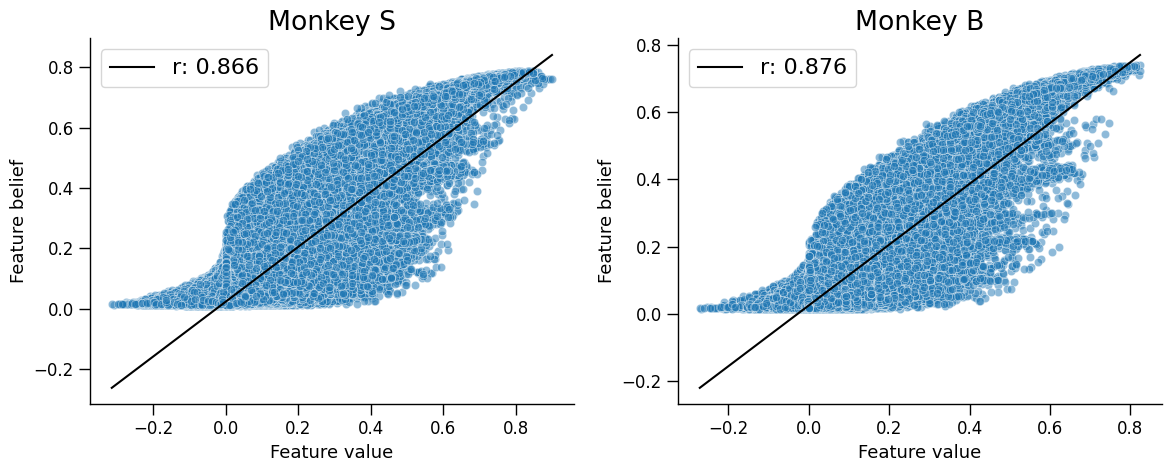

In [2]:
def load_vars(row, sub, model_name):
    data = pd.read_pickle(f"/data/patrick_res/behavior/models/inferred_variables/{model_name}_{sub}/{row.session_name}.pickle")
    data["session"] = row.session_name
    return data


fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for i, sub in enumerate(["SA", "BL"]):
    valid_sessions = pd.read_pickle(SESSIONS_PATH.format(sub=sub))
    beliefs = pd.concat(valid_sessions.apply(lambda x: load_vars(x, sub, "BeliefStateAgent"), axis=1).values)
    feat_values = pd.concat(valid_sessions.apply(lambda x: load_vars(x, sub, "NivFeatRLwDecayAgent"), axis=1).values)
    merged = pd.merge(beliefs, feat_values, on=["TrialNumber", "session"])

    all_beliefs = []
    all_values = []
    for feat in FEATURES:
        all_beliefs.append(merged[f"{feat}Prob"].values)
        all_values.append(merged[f"{feat}Value"].values)
    all_values = np.concatenate(all_values)

    # spearman_r, _ = spearmanr(all_beliefs, all_values)
    # pearson_r, _ = pearsonr(all_beliefs, all_values)

    ax = axs[i]
    print(len(all_values))
    _, _, r_value, _, _ = visualization_utils.plot_and_calc_correlation(np.array(all_values), np.array(all_beliefs), ax)
    ax.set_title(f"Monkey {'S' if sub == 'SA' else 'B'}")
    ax.set_xlabel("Feature value")
    ax.set_ylabel("Feature belief")
    ax.legend()
visualization_utils.format_plot(axs)
fig.tight_layout()
fig.savefig("/data/patrick_res/figures/wcst_paper/behavior/beliefs_values_correlations.png", dpi=300)
fig.savefig("/data/patrick_res/figures/wcst_paper/behavior/beliefs_values_correlations.svg")

